In [46]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [47]:
import matplotlib.pyplot as plt

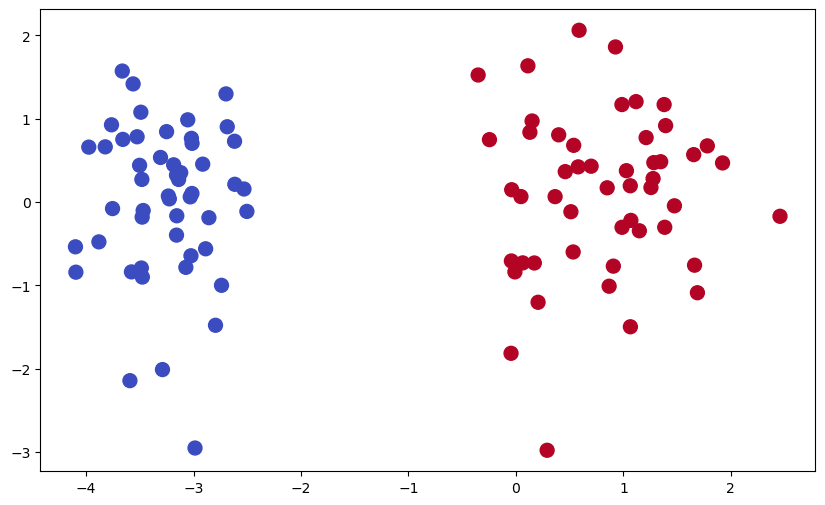

In [48]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',s=100)

In [80]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [81]:
print(lor.coef_)
print(lor.intercept_)



[[4.79501884 0.2081534 ]]
[5.76866215]


In [82]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_[0]/lor.coef_[0][1])

In [83]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [90]:
def gd(X,y):
    X = np.insert(X,0,1,axis=1)# add bias term
    weights = np.ones(X.shape[1])# initialize weights
    lr = 0.5# learning rate

    for i in range(2500):
        y_hat = sigmoid(np.dot(X,weights))# predicted values
        weights  = weights + lr *(np.dot((y - y_hat), X) / X.shape[0])

    return weights[1:],weights[0]



In [91]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [92]:
coef_,intercept_ = gd(X,y)

In [93]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [94]:
X_input = np.linspace(-3,3,100)
Y_input = m*X_input + b

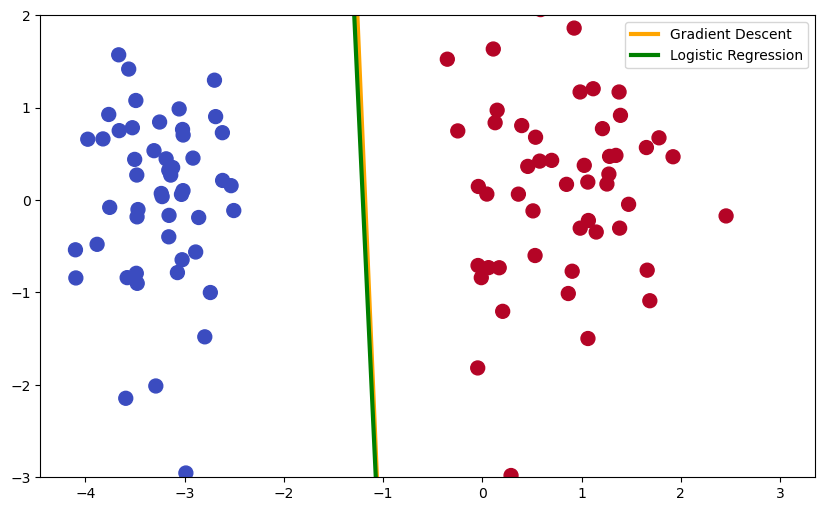

In [95]:
plt.figure(figsize=(10,6))
plt.plot(X_input,Y_input,color='orange',label='Gradient Descent',linewidth=3)
plt.plot(x_input,y_input,color='green',label='Logistic Regression',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm',s=100)
plt.ylim(-3,2)
plt.legend()